# Exploratory Data Analysis & Intro

## Goal
1. Investigate top-paying roles and skills in the data science industry.
2. use Python to explore a real-live dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities.

## Final Deliverables:

* Create Jupyter Notebooks (showcasing core skills in Python).
* Create a summary page (via README.md) capturing your findings.
* Share this project via GitHub & LinkedIn.

# Exploratory Data Analysis

## Roles to Explore:

In [7]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

## Filter for US Data Analyst Roles

In [19]:
#Filter for data analyst
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

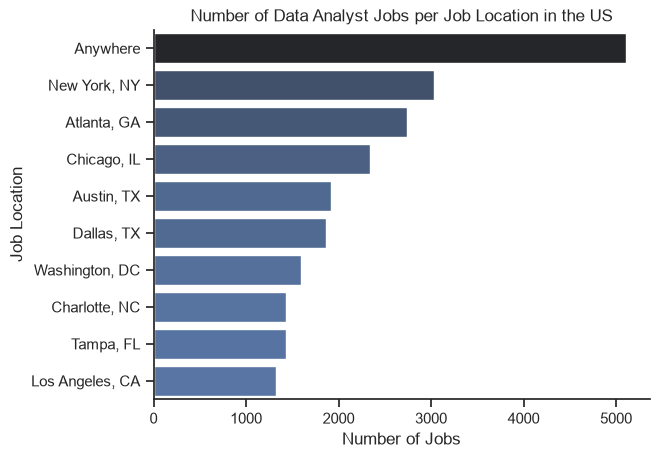

In [20]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette = 'dark:b_r')
sns.despine()
plt.title('Number of Data Analyst Jobs per Job Location in the US')
plt.ylabel('Job Location')
plt.xlabel('Number of Jobs')
plt.legend().remove()
plt.show()

0 job_work_from_home Work from Home
1 job_no_degree_mention Job Degree Req.
2 job_health_insurance Health Insurance Offered


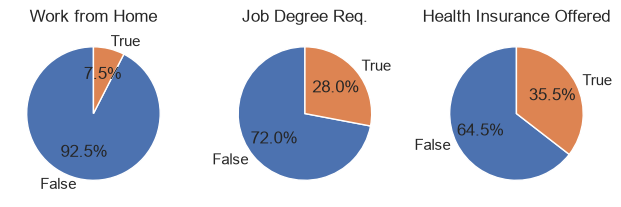

In [21]:
fig,ax = plt.subplots(1,3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()): #(column, title) as tuple because they are defined as a dictionary
    print(i,column,title)
    ax[i].pie(df_DA_US[column].value_counts(),startangle=90,autopct='%1.1f%%', labels = ['False','True'])
    ax[i].set_title(title)

fig.tight_layout()
plt.show()

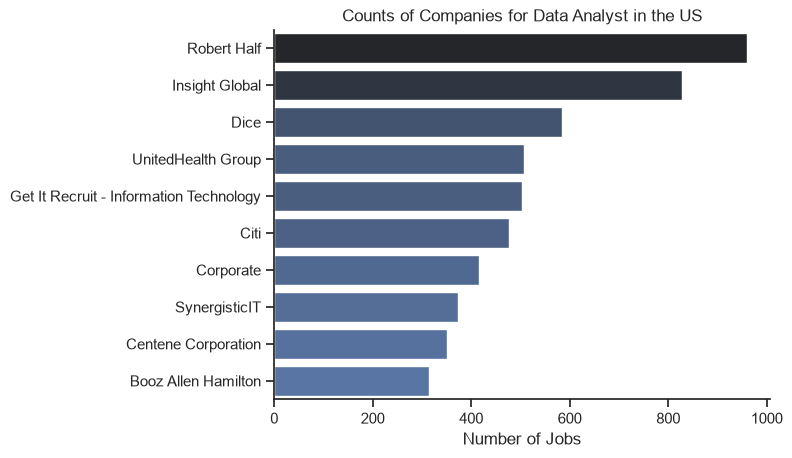

In [22]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette = 'dark:b_r')
sns.despine()
plt.title('Counts of Companies for Data Analyst in the US')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.legend().remove()
plt.show()